In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

#_set_env("GEMINI_API_KEY")
_set_env("GEMINI_API_KEY")

GEMINI_API_KEY:  ········


In [2]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

LANGSMITH_API_KEY:  ········


In [3]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="AI")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lai"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lai

Yes, I know about whales. But what others should I learn about?


In [4]:
#from langchain_openai import ChatOpenAI
#llm = ChatOpenAI(model="gpt-4o")
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)
answer=llm.invoke(messages)

In [5]:
answer.pretty_print()

================================== Ai Message ==================================

Excellent! Beyond whales (which are cetaceans, including dolphins and porpoises), the ocean is teeming with other incredible mammals. Here are the main groups you should definitely learn about:

1.  **Pinnipeds (Fin-footed Mammals):** This group includes seals, sea lions, and walruses. They are characterized by their flippers, which they use for swimming.

    *   **Seals (True Seals / Phocidae):**
        *   **Characteristics:** No external ear flaps, move on land by "wiggling" their bodies (they can't rotate their hind flippers forward), swim primarily with their powerful hind flippers.
        *   **Examples:** Harbor seals, Grey seals, Harp seals, Ringed seals, Leopard seals, Elephant seals (the largest seals, known for their proboscis).
        *   **Fun Fact:** Many species are excellent divers, holding their breath for impressive lengths of time.

    *   **Sea Lions (Eared Seals / Otariidae):**
 

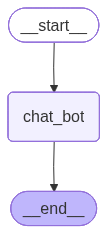

In [34]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

def format_message(text: str) -> MessagesState:
    return {'messages': text}

def chat_message_node(state:MessagesState) -> MessagesState:
    return format_message(llm.invoke(state['messages']))

builder=StateGraph(MessagesState)
builder.add_node('chat_bot', chat_message_node)
builder.add_edge(START, 'chat_bot')
builder.add_edge('chat_bot', END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [22]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lai

Yes, I know about whales. But what others should I learn about?


In [35]:
output=graph.invoke(format_message(messages))

In [36]:
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lai

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Excellent! Beyond whales (which are cetaceans, including dolphins and porpoises), the ocean is teeming with other incredible mammals. Here are the main groups you should definitely learn about:

1.  **Pinnipeds (Fin-footed Mammals):** This group includes seals, sea lions, and walruses. They are characterized by their flippers, which they use for swimming.

    *   **Seals (True Seals / Phocidae):**
        *   **Characteristics:** No external ear flaps, move on land by "wiggling" their bodies (they can't rotate their hind flippers forward), swim primarily with their powerful hind flippers.
        *   **Examples:** 

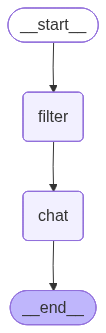

In [40]:
from langchain_core.messages import RemoveMessage

def filter_msg(state:MessagesState):
    dlt_messages=[RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return format_message(dlt_messages)

def chat_node(state:MessagesState):
    return format_message(llm.invoke(state['messages']))

builder=StateGraph(MessagesState)
builder.add_node('filter', filter_msg)
builder.add_node('chat', chat_node)
builder.add_edge(START, 'filter')
builder.add_edge('filter','chat')
builder.add_edge('chat',END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [50]:
messages=[AIMessage('hi',name='Ai',id='1')]
messages.append(HumanMessage('hi',name='Lai',id='2'))
messages.append(AIMessage('how can I help you?',name='Ai',id='3'))
messages.append(HumanMessage('what is the Catholic reading of Bible for this coming Sunday?',name='Lai',id='4'))
output=graph.invoke(format_message(messages))

for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Ai

how can I help you?
================================ Human Message =================================
Name: Lai

what is the Catholic reading of Bible for this coming Sunday?
================================== Ai Message ==================================

For this coming Sunday, **June 16, 2024**, the Catholic Church celebrates the **Eleventh Sunday in Ordinary Time, Year B**.

Here are the readings:

1.  **First Reading:** **Ezekiel 17:22-24**
    *   This reading speaks of God taking a tender shoot from the top of a cedar and planting it on a high mountain, where it will grow into a majestic cedar, providing shelter for all birds. It's a prophecy about God's power to raise up the humble and bring down the mighty, often interpreted as a foreshadowing of Christ and the growth of His Church.

2.  **Responsorial Psalm:** **Psalm 92:2-3, 13-14, 15 (R. "Lord, it is good to give thanks to you.")**
   

In [51]:
messages.append(output['messages'][-1])
messages.append(HumanMessage("I am preparing this weekend's Bible study. Provide me the context for the First Reading.", name='Lai', id=f'{len(messages)+1}'))
                



In [53]:
messages[-1].pretty_print()

================================ Human Message =================================
Name: Lai

I am preparing this weekend's Bible study. Provide me the context for the First Reading.


In [54]:
output=graph.invoke(format_message(messages))

In [55]:
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================

For this coming Sunday, **June 16, 2024**, the Catholic Church celebrates the **Eleventh Sunday in Ordinary Time, Year B**.

Here are the readings:

1.  **First Reading:** **Ezekiel 17:22-24**
    *   This reading speaks of God taking a tender shoot from the top of a cedar and planting it on a high mountain, where it will grow into a majestic cedar, providing shelter for all birds. It's a prophecy about God's power to raise up the humble and bring down the mighty, often interpreted as a foreshadowing of Christ and the growth of His Church.

2.  **Responsorial Psalm:** **Psalm 92:2-3, 13-14, 15 (R. "Lord, it is good to give thanks to you.")**
    *   This psalm praises God for His goodness and faithfulness, comparing the righteous to palm trees and cedars that flourish in the courts of the Lord, bearing fruit even in old age.

3.  **Second Reading:** **2 Corinthians 5:6-10**
    *   St. Paul reflects on th

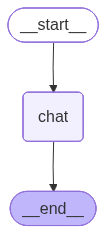

In [68]:
# trim 

from langchain_core.messages import trim_messages
from langchain_openai import ChatOpenAI

def trim_chat_node (state:MessagesState):
    trimed=trim_messages(
        state['messages'],
        max_tokens=100,
        strategy='last',
        token_counter=llm,
        allow_partial=False
    )
    return {'messages':[llm.invoke(trimed)]}



builder=StateGraph(MessagesState)
builder.add_node('chat',trim_chat_node)
builder.add_edge(START, 'chat')
builder.add_edge('chat',END)
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [76]:
len(messages)

6

In [72]:
trimed=trim_messages(
        messages,
        max_tokens=100,
        strategy='last',
        token_counter=llm,
        allow_partial=False
    )

In [73]:
trimed

[HumanMessage(content="I am preparing this weekend's Bible study. Provide me the context for the First Reading.", additional_kwargs={}, response_metadata={}, name='Lai', id='6')]

In [79]:
output=graph.invoke({'messages':messages})

In [80]:
for m in output['messages']:
    m.pretty_print()
    

================================== Ai Message ==================================
Name: Ai

hi
================================ Human Message =================================
Name: Lai

hi
================================== Ai Message ==================================
Name: Ai

how can I help you?
================================ Human Message =================================
Name: Lai

what is the Catholic reading of Bible for this coming Sunday?
================================== Ai Message ==================================

For this coming Sunday, **June 16, 2024**, the Catholic Church celebrates the **Eleventh Sunday in Ordinary Time, Year B**.

Here are the readings:

1.  **First Reading:** **Ezekiel 17:22-24**
    *   This reading speaks of God taking a tender shoot from the top of a cedar and planting it on a high mountain, where it will grow into a majestic cedar, providing shelter for all birds. It's a prophecy about God's power to raise up the humble and bring down the mig

In [81]:
# summary

class sum_state(MessagesState):
    summary: str

In [82]:
from langchain_core.messages import SystemMessage

def call_model (state: sum_state): 
    summary = state.get('summary','') 
    if summary: 
        sys_msg=f'Summary of the previous conversation: {summary}'
        messages = [SystemMessage(content=sys_msg)] + state['messages']
    else:
        messages=state['messages']
    response = llm.invoke(messages)
    return {'messages':response}

In [85]:
def summarize(state: sum_state):
    summary = state.get('summary','') 
    if summary: 
        sum_msg=f'Here is the summary of previous conversation: {summary}\n\n'
        'expand the summary to include the new message above: '
    else: 
        sum_msg="Summerize the above conversasion"
    messages=state['messages']+ [HumanMessage(sum_msg)]
    response = llm.invoke(messages)
    # keep the last 2 messages
    dlt_msg=[RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return {'summary':response.content, 'messages':dlt_msg}
    

In [139]:
from langgraph.graph import END
from typing_extensions import Literal

def should_condition(state: sum_state) -> Literal[END,'summarize']:
    summary = state.get('summary','') 
    if len(state['messages'])>6 or summary: 
        return 'summarize'
    else: 
        return END
    

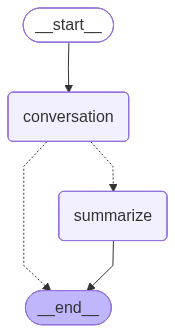

In [140]:
from IPython.display import Image, display 
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

builder = StateGraph(sum_state) 
builder.add_node('conversation',call_model)
builder.add_node('summarize',summarize)

builder.add_edge(START,'conversation')
builder.add_conditional_edges('conversation',should_condition)
builder.add_edge('summarize', END)

memory=MemorySaver()
graph=builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))


In [141]:
config = {"configurable": {"thread_id": "1"}}

input_msg=HumanMessage(content='Help me plan a trip to Maui, HI.')
output=graph.invoke({'messages':[input_msg]},config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Aloha! Maui is an absolutely incredible choice for a Hawaiian vacation. Known as "The Valley Isle," it offers a perfect blend of stunning beaches, lush landscapes, volcanic wonders, vibrant culture, and delicious food.

To help you plan, let's break it down into key stages. Tell me a bit more about your preferences as we go, but here's a comprehensive starting point:

---

## Phase 1: Pre-Planning & Logistics

### 1. Best Time to Visit

*   **Peak Season (December - April):** Cooler, less humid, whale watching season (mid-December to mid-May), but higher prices and more crowds, especially around holidays.
*   **Shoulder Season (April - May & September - November):** Great weather, fewer crowds, better deals on flights and accommodation. My personal favorite times to visit.
*   **Off-Season (June - August):** Hotter and more humid, but still beautiful. Good for calm waters for snorkeling/diving. Can be bus

In [142]:
input_message = HumanMessage(content="how is the weather there in early June? limited the answer to max 100 tokens")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Early June in Maui is typically warm and sunny, with average temperatures in the high 70s to mid-80s°F (25-30°C). It's generally dry with minimal rain, especially on the leeward (west/south) sides. Humidity starts to increase, and ocean waters are calm and inviting.


In [143]:
input_message = HumanMessage(content="how are the restaurants there? limited the answer to max 100 tokens")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Maui boasts a diverse culinary scene, from casual food trucks and local eateries to upscale fine dining. Expect fresh, local ingredients, especially seafood and farm-to-table options. You'll find diverse cuisines, unique Hawaiian flavors, and experiences like luaus. Prices vary, but quality is generally high.


In [144]:
# Latest state — fully decoded
state = graph.get_state({"configurable": {"thread_id": "1"}})
print(f"Messages in thread 1: {len(state.values['messages'])}")
for m in state.values["messages"]:
    m.pretty_print()

Messages in thread 1: 6
================================ Human Message =================================

Help me plan a trip to Maui, HI.
================================== Ai Message ==================================

Aloha! Maui is an absolutely incredible choice for a Hawaiian vacation. Known as "The Valley Isle," it offers a perfect blend of stunning beaches, lush landscapes, volcanic wonders, vibrant culture, and delicious food.

To help you plan, let's break it down into key stages. Tell me a bit more about your preferences as we go, but here's a comprehensive starting point:

---

## Phase 1: Pre-Planning & Logistics

### 1. Best Time to Visit

*   **Peak Season (December - April):** Cooler, less humid, whale watching season (mid-December to mid-May), but higher prices and more crowds, especially around holidays.
*   **Shoulder Season (April - May & September - November):** Great weather, fewer crowds, better deals on flights and accommodation. My personal favorite times to vi

In [147]:
smry=graph.get_state(config).values.get('summary')
print(smry)

None


In [148]:
input_message = HumanMessage(content="anyplace for hiking? limited the answer to max 100 tokens")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Absolutely! Maui offers fantastic hiking. Popular spots include **Haleakala National Park** (crater trails), **Iao Valley State Park** (lush, easy walks), and numerous trails along the **Road to Hana** (waterfalls, rainforest). Coastal paths and shorter resort trails also provide scenic options.


In [153]:
smry=graph.get_state(config).values.get('summary')
print(smry)

Thanks for the excellent summary! It's a great overview of our discussion so far, covering key aspects of a Maui trip.

I'm ready for your next question or if you'd like to dive deeper into any of these topics!


In [150]:
input_message = HumanMessage(content="give me 3 places to visit for natural view. limited the answer to max 100 tokens")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Three must-visit natural view spots:

1.  **Haleakala Summit:** Otherworldly volcanic crater, incredible sunrise/sunset.
2.  **Road to Hana:** Lush rainforests, countless waterfalls, dramatic coastal vistas.
3.  **Iao Valley State Park:** Iconic Iao Needle, emerald-green mountains, serene landscapes.


In [151]:
# Latest state — fully decoded
state = graph.get_state({"configurable": {"thread_id": "1"}})
print(f"Messages in thread 1: {len(state.values['messages'])}")
for m in state.values["messages"]:
    m.pretty_print()

Messages in thread 1: 2
================================ Human Message =================================

give me 3 places to visit for natural view. limited the answer to max 100 tokens
================================== Ai Message ==================================

Three must-visit natural view spots:

1.  **Haleakala Summit:** Otherworldly volcanic crater, incredible sunrise/sunset.
2.  **Road to Hana:** Lush rainforests, countless waterfalls, dramatic coastal vistas.
3.  **Iao Valley State Park:** Iconic Iao Needle, emerald-green mountains, serene landscapes.


In [155]:
input_message = HumanMessage(content="where was the first hiking spot you suggested earlier?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

The first specific place I suggested that offers significant hiking opportunities was **Haleakala Summit**.


In [156]:
graph.get_state(config).values.get('messages')


"Great! I'm glad the summary was helpful.\n\nSince we've covered a good overview of Maui, what aspect are you most interested in exploring further right now? We could:\n\n1.  **Dive deeper into specific activities** (e.g., best snorkeling spots, detailed hiking info, luau recommendations).\n2.  **Look at accommodation options** in more detail based on your preferences.\n3.  **Discuss transportation logistics** and rental car tips.\n4.  **Start thinking about a potential itinerary** for your trip.\n\nLet me know what's on your mind!"